<p style="text-align: center; font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;">
LoRaWAN Indoor Dataset: Distance Estimation
</p>

This notebook performs distance estimation by inverting the path loss models fitted in `03_Path_Loss_Modeling.ipynb`. It reads the filtered test set from `02_Kalman_Filtering.ipynb` and the saved model parameters from `03_Path_Loss_Modeling.ipynb`, then evaluates distance estimation performance using MAE, RMSE, median error, CDFs, and relative-error plots.

### Distance Estimation for Localization


In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from scipy.stats import wilcoxon
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch, Rectangle

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
sns.set_context("talk", font_scale=0.9)

In [70]:
TEST_PATH = 'Data Files/test_kf.csv'
PARAMS_PATH = 'Data Files/path_loss_params.npz'

required_cols = {
    'device_id', 'time',
    'rssi', 'filtered_rssi',
    'exp_pl', 'exp_pl_filtered',
    'distance', 'frequency', 'c_walls', 'w_walls',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature', 'snr'
}

test_df = pd.read_csv(TEST_PATH, parse_dates=['time'])

missing_test = required_cols - set(test_df.columns)
if missing_test:
    raise ValueError(
        f"Missing columns in test set: {missing_test}. "
        "Rerun 02_Kalman_Filtering.ipynb."
    )

artifacts = np.load(PARAMS_PATH)

required_params = {'popt_mw_raw', 'popt_ep_raw', 'popt_mw_filt', 'popt_ep_filt'}
missing_params = required_params - set(artifacts.files)
if missing_params:
    raise ValueError(
        f"Missing fitted model parameters: {missing_params}. "
        "Rerun 03_Path_Loss_Modeling.ipynb."
    )

popt_mw_raw = artifacts['popt_mw_raw']
popt_ep_raw = artifacts['popt_ep_raw']
popt_mw_filt = artifacts['popt_mw_filt']
popt_ep_filt = artifacts['popt_ep_filt']

test_df = test_df.sort_values('time').reset_index(drop=True)

print("Loaded filtered test data from 02_Kalman_Filtering.ipynb")
print("Loaded fitted path loss parameters from 03_Path_Loss_Modeling.ipynb")
print(f"test_df shape: {test_df.shape}")
print(f"Test window: {test_df['time'].min()} -> {test_df['time'].max()}")

display(test_df.head())

Loaded filtered test data from 02_Kalman_Filtering.ipynb
Loaded fitted path loss parameters from 03_Path_Loss_Modeling.ipynb
test_df shape: (415907, 16)
Test window: 2025-08-12 17:19:02.126782+00:00 -> 2025-09-30 23:59:55.971870+00:00


,device_id,time,rssi,filtered_rssi,exp_pl,exp_pl_filtered,distance,frequency,c_walls,w_walls,co2,humidity,pm25,pressure,temperature,snr
0,ED4,2025-08-12 17:19:02.126782+00:00,-84.0,-84.0,101.26,101.26,37,868.5,0,5,454.0,36.31,2.50,321.97,29.12,9.2
1,ED0,2025-08-12 17:19:19.243640+00:00,-51.0,-51.0,68.26,68.26,10,867.7,0,0,411.0,35.23,10.15,319.99,29.33,12.0
2,ED3,2025-08-12 17:19:21.750967+00:00,-69.0,-69.0,86.26,86.26,18,868.1,1,2,430.0,24.39,6.00,320.50,42.69,12.0
3,ED1,2025-08-12 17:19:44.308397+00:00,-54.0,-54.0,71.26,71.26,8,867.5,1,0,424.0,35.60,6.02,320.96,29.76,9.0
4,ED5,2025-08-12 17:19:49.123572+00:00,-94.0,-94.0,111.26,111.26,40,867.9,2,2,440.0,40.62,8.27,320.54,27.01,12.0


In [71]:
# Define Distance Inversion Functions for distance estimation
def estimate_distance_modelA(PL, PL_d0, n, L_c, L_w, W_c, W_w):
    # MWM: Model A
    # PL = PL(d0) + 10*n*log10(d) + (W_c*L_c + W_w*L_w) + ε
    return 10 ** ((PL - PL_d0 - (W_c * L_c + W_w * L_w)) / (10 * n))

def estimate_distance_modelB(PL, PL_d0, n, L_c, L_w, f, theta_E, E_matrix, k_snr, SNR, W_c, W_w):
    # MWM-EP: Model B
    # PL = PL(d0) + 10*n*log10(d) + 20*log10(f) + (W_c*L_c + W_w*L_w)
    #      + (θ1*E1 + ... + θ5*E5) + k_SNR*SNR + ε
    env_term = np.dot(theta_E, E_matrix)  # E_matrix shape: (5, number_of_samples)
    return 10 ** ((PL - PL_d0 - 20*np.log10(f) - (W_c * L_c + W_w * L_w) - env_term - k_snr * SNR) / (10 * n))

# Prepare Environmental Data; particularly for Model B
E_matrix_test = np.array([
    test_df['co2'].values,
    test_df['humidity'].values,
    test_df['pm25'].values,
    test_df['pressure'].values,
    test_df['temperature'].values
])
f_test   = test_df['frequency'].values
W_c_test = test_df['c_walls'].values
W_w_test = test_df['w_walls'].values
SNR_test = test_df['snr'].values

# Compute Distance Estimates (using full PL)
# Model A (MWM)
d_A_raw = estimate_distance_modelA(
    PL = test_df['exp_pl'].values,
    PL_d0 = popt_mw_raw[0],
    n = popt_mw_raw[1],
    L_c = popt_mw_raw[2],
    L_w = popt_mw_raw[3],
    W_c = W_c_test,
    W_w = W_w_test
)
d_A_filt = estimate_distance_modelA(
    PL = test_df['exp_pl_filtered'].values,
    PL_d0 = popt_mw_filt[0],
    n = popt_mw_filt[1],
    L_c = popt_mw_filt[2],
    L_w = popt_mw_filt[3],
    W_c = W_c_test,
    W_w = W_w_test
)

# Model B (MWM-EP)
theta_E_raw  = popt_ep_raw[4:9]
theta_E_filt = popt_ep_filt[4:9]

d_B_raw = estimate_distance_modelB(
    PL = test_df['exp_pl'].values,
    PL_d0 = popt_ep_raw[0],
    n = popt_ep_raw[1],
    L_c = popt_ep_raw[2],
    L_w = popt_ep_raw[3],
    f = f_test,
    theta_E = theta_E_raw,
    E_matrix = E_matrix_test,
    k_snr = popt_ep_raw[9],
    SNR = SNR_test,
    W_c = W_c_test,
    W_w = W_w_test
)
d_B_filt = estimate_distance_modelB(
    PL = test_df['exp_pl_filtered'].values,
    PL_d0 = popt_ep_filt[0],
    n = popt_ep_filt[1],
    L_c = popt_ep_filt[2],
    L_w = popt_ep_filt[3],
    f = f_test,
    theta_E = theta_E_filt,
    E_matrix = E_matrix_test,
    k_snr = popt_ep_filt[9],
    SNR = SNR_test,
    W_c = W_c_test,
    W_w = W_w_test
)

#### Analysis Metrics for Comparison

In [72]:
# Compute Metrics for Model Comparison
def compute_metrics(true, pred):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    median_err = np.median(np.abs(true - pred))
    r2 = r2_score(true, pred)
    return mae, rmse, median_err, r2

true_distance = test_df['distance'].values

metrics_neglected = {
    'MWM': compute_metrics(true_distance, d_A_raw),
    'MWM-KF': compute_metrics(true_distance, d_A_filt),
    'MWM-EP': compute_metrics(true_distance, d_B_raw),
    'MWM-EP-KF': compute_metrics(true_distance, d_B_filt)
}

metrics_df_neglected = pd.DataFrame(metrics_neglected, index=['MAE', 'RMSE', 'Median Error', 'R²'])

print("\n Distance Estimation Metrics \n")
display(metrics_df_neglected)


 Distance Estimation Metrics 



,MWM,MWM-KF,MWM-EP,MWM-EP-KF
MAE,14.823318,4.930372,8.771957,4.934423
RMSE,52.178118,7.183404,16.253023,7.209375
Median Error,4.212146,3.270011,4.795890,3.262315
R²,-16.996574,0.658906,-0.746149,0.656436


In [73]:
metrics_df_neglected.to_csv('Data Files/distance_metrics.csv', index=True)

distance_predictions_df = test_df[['device_id', 'time', 'distance']].copy()
distance_predictions_df['MWM'] = d_A_raw
distance_predictions_df['MWM-KF'] = d_A_filt
distance_predictions_df['MWM-EP'] = d_B_raw
distance_predictions_df['MWM-EP-KF'] = d_B_filt

distance_predictions_df.to_csv('Data Files/distance_predictions.csv', index=False)

print("Saved:")
print("  Data Files/distance_metrics.csv")
print("  Data Files/distance_predictions.csv")

Saved:
  Data Files/distance_metrics.csv
  Data Files/distance_predictions.csv


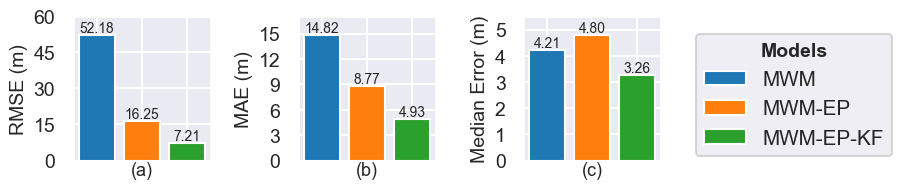

In [74]:
# Define the subset of models to compare
model_subset = ['MWM', 'MWM-EP', 'MWM-EP-KF']

# Extract RMSE, MAE, Median Error values from your metrics dataframe
rmse_values   = metrics_df_neglected.loc['RMSE', model_subset]
mae_values    = metrics_df_neglected.loc['MAE', model_subset]
median_values = metrics_df_neglected.loc['Median Error', model_subset]

# Create subplots for RMSE, MAE, and Median Error
fig, axs = plt.subplots(1, 3, figsize=(7, 2.2))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# (a) RMSE plot
bars_a = axs[0].bar(model_subset, rmse_values, color=colors)
axs[0].set_ylabel('RMSE (m)', fontsize=14)
axs[0].tick_params(axis='x', bottom=False, labelbottom=False)
axs[0].tick_params(axis='y', labelsize=14)
axs[0].text(0.5, -0.1, '(a)', transform=axs[0].transAxes,
            fontsize=13, ha='center')
for bar, label in zip(bars_a, model_subset):
    bar.set_label(label)

# (b) MAE plot
bars_b = axs[1].bar(model_subset, mae_values, color=colors)
axs[1].set_ylabel('MAE (m)', fontsize=14)
axs[1].tick_params(axis='x', bottom=False, labelbottom=False)
axs[1].tick_params(axis='y', labelsize=14)
axs[1].text(0.5, -0.1, '(b)', transform=axs[1].transAxes,
            fontsize=13, ha='center')

# (c) Median Error plot
bars_c = axs[2].bar(model_subset, median_values, color=colors)
axs[2].set_ylabel('Median Error (m)', fontsize=14)
axs[2].tick_params(axis='x', bottom=False, labelbottom=False)
axs[2].tick_params(axis='y', labelsize=14)
axs[2].text(0.5, -0.1, '(c)', transform=axs[2].transAxes,
            fontsize=13, ha='center')

# Set each subplot's y-axis to have roughly 6 ticks
for ax in axs:
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))

# Set border (spine) width for both subplots and annotate bar values
for ax in axs:
    [s.set_linewidth(2) for s in ax.spines.values()]
    for bar in ax.patches:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    (bar.get_x() + bar.get_width() / 2, height),
                    ha='center', va='bottom', fontsize=10,
                    clip_on=True)
    # Add headroom for bar labels
    y_max = max(bar.get_height() for bar in ax.patches)
    ax.set_ylim(top=y_max * 1.15)  # 15% headroom

# Create a common legend on the right-hand side with one column
handles, labels = axs[0].get_legend_handles_labels()
legend = fig.legend(handles, labels, loc='center left',
                    bbox_to_anchor=(1.0, 0.5), ncol=1, title='Models')
legend.get_title().set_fontsize(14)
legend.get_title().set_fontweight('bold')

# Adjust layout to make room for the right-hand side legend
plt.subplots_adjust(right=0.85, bottom=0.15)
plt.tight_layout()
plt.show()

In [75]:
# Compute absolute errors and CDF for both models

def compute_cdf(errors, bins=100):
    hist_vals, bin_edges = np.histogram(errors, bins=bins, density=True)
    cdf_vals = np.cumsum(hist_vals * np.diff(bin_edges))
    return bin_edges[1:], cdf_vals

error_A_raw  = np.abs(true_distance - d_A_raw)
error_A_filt = np.abs(true_distance - d_A_filt)
error_B_raw  = np.abs(true_distance - d_B_raw)
error_B_filt = np.abs(true_distance - d_B_filt)

x_A_raw,  cdf_A_raw  = compute_cdf(error_A_raw)
x_A_filt, cdf_A_filt = compute_cdf(error_A_filt)
x_B_raw,  cdf_B_raw  = compute_cdf(error_B_raw)
x_B_filt, cdf_B_filt = compute_cdf(error_B_filt)

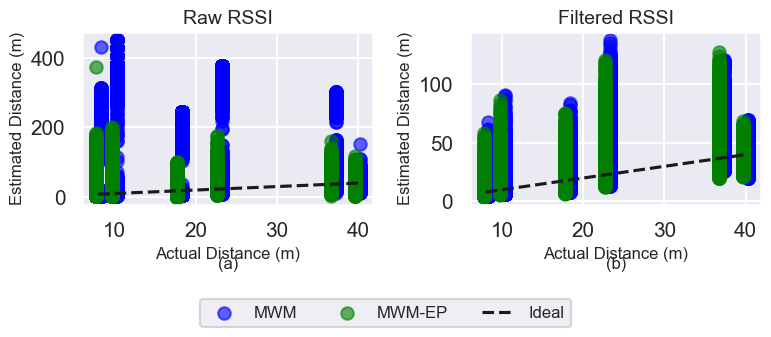

In [76]:
# Scatter Plots (2x1 for estimated vs actual distance)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Define a jitter value for visual separation
jitter = 0.3

def plot_scatter(ax, actual, pred_A, pred_B, title):
    # Add jitter to actual distances for MWM and Model B
    ax.scatter(actual + jitter, pred_A, alpha=0.6, label='MWM', color='blue')
    ax.scatter(actual - jitter, pred_B, alpha=0.6, label='MWM-EP', color='green')
    ax.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'k--', label='Ideal')
    ax.set_xlabel('Actual Distance (m)', fontsize=12)
    ax.set_ylabel('Estimated Distance (m)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)

# Plot scatter for Raw RSSI and Filtered RSSI
plot_scatter(axes[0], true_distance, d_A_raw, d_B_raw, 'Raw RSSI')
plot_scatter(axes[1], true_distance, d_A_filt, d_B_filt, 'Filtered RSSI')

# Add subplot labels (a) and (b) below each subplot
axes[0].text(0.5, -0.3, '(a)', transform=axes[0].transAxes,
             fontsize=12, ha='center', va='top')
axes[1].text(0.5, -0.3, '(b)', transform=axes[1].transAxes,
             fontsize=12, ha='center', va='top')

# Collect handles/labels from both subplots
handles_a, labels_a = axes[0].get_legend_handles_labels()
handles_b, labels_b = axes[1].get_legend_handles_labels()
all_handles = handles_a + handles_b
all_labels = labels_a + labels_b

# Remove duplicate legend entries while preserving order
seen = {}
unique_handles = []
unique_labels = []
for h, lbl in zip(all_handles, all_labels):
    if lbl not in seen:
        unique_handles.append(h)
        unique_labels.append(lbl)
        seen[lbl] = True

# Create a single combined legend below the subplots
fig.legend(unique_handles, unique_labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3, fontsize=12)

# Adjust layout to include legend space and save the figure
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

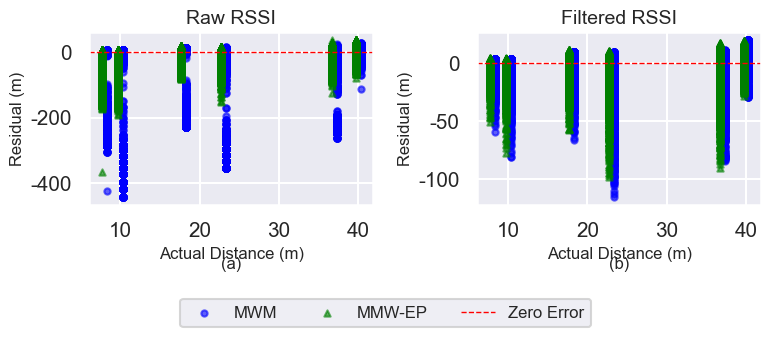

In [77]:
# Create subplots (1 row, 2 columns) for residuals vs actual distance
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Compute residuals for Raw and Filtered RSSI
resid_A_raw  = true_distance - d_A_raw
resid_B_raw  = true_distance - d_B_raw
resid_A_filt = true_distance - d_A_filt
resid_B_filt = true_distance - d_B_filt

# Define function to plot residuals with jitter
def plot_residuals(ax, actual, resid_A, resid_B, title, jitter=0.3):
    # Add jitter to actual distances for Model A and Model B residuals
    ax.scatter(actual + jitter, resid_A, alpha=0.6, s=20, color='blue', marker='o', label='MWM')
    ax.scatter(actual - jitter, resid_B, alpha=0.6, s=20, color='green', marker='^', label='MMW-EP')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero Error')
    ax.set_xlabel('Actual Distance (m)', fontsize=12)
    ax.set_ylabel('Residual (m)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True)

# Plot residuals for Raw and Filtered RSSI
plot_residuals(axes[0], true_distance, resid_A_raw, resid_B_raw, 'Raw RSSI')
plot_residuals(axes[1], true_distance, resid_A_filt, resid_B_filt, 'Filtered RSSI')

# Add subplot labels (a) and (b) below each subplot
axes[0].text(0.5, -0.3, '(a)', transform=axes[0].transAxes,
             fontsize=12, ha='center', va='top')
axes[1].text(0.5, -0.3, '(b)', transform=axes[1].transAxes,
             fontsize=12,  ha='center', va='top')

# Collect handles and labels from both subplots
handles_a, labels_a = axes[0].get_legend_handles_labels()
handles_b, labels_b = axes[1].get_legend_handles_labels()
all_handles = handles_a + handles_b
all_labels = labels_a + labels_b

# Remove duplicate legend entries while preserving order
seen = {}
unique_handles = []
unique_labels = []
for h, lbl in zip(all_handles, all_labels):
    if lbl not in seen:
        unique_handles.append(h)
        unique_labels.append(lbl)
        seen[lbl] = True

# Create a single combined legend below the subplots
fig.legend(unique_handles, unique_labels, loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=3, fontsize=12)

# Adjust layout to include space for the legend
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

In [78]:
# Helper: CDF value at a given threshold
def cdf_at(x, cdf, thr):
    # Make sure x is sorted (just in case)
    idx = np.argsort(x)
    x_sorted = x[idx]
    cdf_sorted = cdf[idx]
    # Linear interpolation of CDF at 'thr'
    return float(np.interp(thr, x_sorted, cdf_sorted, left=0.0, right=1.0))

threshold = 12.0  # metres

p_mwm       = cdf_at(x_A_raw,  cdf_A_raw,  threshold)
p_mwm_ep    = cdf_at(x_B_raw,  cdf_B_raw,  threshold)
p_mwm_ep_kf = cdf_at(x_B_filt, cdf_B_filt, threshold)

print(f"P(|e| ≤ {threshold:.0f} m):")
print(f"  MWM       : {p_mwm*100:.2f}%")
print(f"  MWM-EP    : {p_mwm_ep*100:.2f}%")
print(f"  MWM-EP-KF : {p_mwm_ep_kf*100:.2f}%")

P(|e| ≤ 12 m):
  MWM       : 87.53%
  MWM-EP    : 80.91%
  MWM-EP-KF : 91.70%


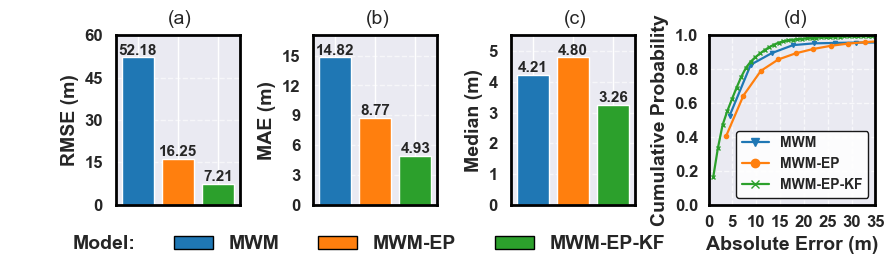

In [79]:
# Vector-friendly PDF output
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['savefig.dpi']  = 300

# 1×4: RMSE | MAE | Median | CDF (shared key)

# Tunable typography
FS_LABEL  = 14
FS_TICK   = 12
FS_LEGEND = 10
FS_ANN    = 11

# Palette (consistent across panels)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
model_subset = ['MWM', 'MWM-EP', 'MWM-EP-KF']

# Pull metrics from your DataFrame
rmse_values   = metrics_df_neglected.loc['RMSE',         model_subset]
mae_values    = metrics_df_neglected.loc['MAE',          model_subset]
median_values = metrics_df_neglected.loc['Median Error', model_subset]

# Theme
sns.set_theme(style="darkgrid")

# Layout: give the CDF a bit more horizontal space than each bar panel
fig, axs = plt.subplots(1, 4, figsize=(9.8, 2.2), gridspec_kw={'width_ratios': [1.0, 1.0, 1.0, 1.35], 'wspace': 0.55})

# Helper for bar panels
def make_bar_panel(ax, values, ylabel, panel_tag):
    bars = ax.bar(model_subset, values, color=colors, zorder=3)
    ax.set_ylabel(ylabel, fontsize=FS_LABEL, fontweight='bold')
    ax.tick_params(axis='x', bottom=False, labelbottom=False)
    ax.tick_params(axis='y', labelsize=FS_TICK)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(True, axis='y', linestyle='--', alpha=0.6, zorder=0)
    # annotate bars + headroom
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.2f}', (b.get_x() + b.get_width() / 2, h), ha='center', va='bottom', fontsize=FS_ANN, fontweight='bold', clip_on=True)
    ymax = max(b.get_height() for b in bars) if len(bars) else 1.0
    ax.set_ylim(top=ymax * 1.15)
    # panel tag (non-bold)
    ax.text(0.52, 1.15, panel_tag, transform=ax.transAxes, fontsize=FS_LABEL, ha='center', va='top')

# (a) RMSE
make_bar_panel(axs[0], rmse_values, 'RMSE (m)', '(a)')
# (b) MAE
make_bar_panel(axs[1], mae_values, 'MAE (m)', '(b)')
# (c) Median
make_bar_panel(axs[2], median_values, 'Median (m)', '(c)')

# (d) CDF
ax = axs[3]
ax.plot(x_A_raw,  cdf_A_raw,  label='MWM',       color=colors[0], marker='v', markersize=3, linewidth=1.6, zorder=3)
ax.plot(x_B_raw,  cdf_B_raw,  label='MWM-EP',    color=colors[1], marker='o', markersize=3, linewidth=1.6, zorder=3)
ax.plot(x_B_filt, cdf_B_filt, label='MWM-EP-KF', color=colors[2], marker='x', markersize=3, linewidth=1.6, zorder=3)

ax.set_xlabel('Absolute Error (m)', fontsize=FS_LABEL, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=FS_LABEL, fontweight='bold')
ax.set_xlim(0, 35)
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.0, length=4)
ax.grid(True, linestyle='--', alpha=0.7, zorder=0)

# Legend INSIDE panel (d)
leg = ax.legend(loc='lower right', fontsize=FS_LEGEND, frameon=True, markerscale=2, prop={'weight': 'bold', 'size': FS_LEGEND})
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.9)

# panel tag (non-bold)
ax.text(0.52, 1.15, '(d)', transform=ax.transAxes, fontsize=FS_LABEL, ha='center', va='top')

# Force solid black spines across all panels
for a in axs:
    for s in a.spines.values():
        s.set_visible(True)
        s.set_linewidth(2.0)
        s.set_color('black')
        s.set_zorder(10)

# Make all tick labels bold
for a in axs:
    for lbl in a.get_xticklabels() + a.get_yticklabels():
        lbl.set_fontweight('bold')

#  Horizontal "Model Key" legend under first three models 
dummy = Patch(facecolor='none', edgecolor='none')
patches = [Patch(facecolor=colors[i], edgecolor='black') for i in range(3)]
legend_handles = [dummy] + patches
legend_labels  = ['Model:', 'MWM', 'MWM-EP', 'MWM-EP-KF']

fig.legend(legend_handles, legend_labels, loc='lower center', bbox_to_anchor=(0.355, -0.19), ncol=4, fontsize=14, frameon=False)
model_leg = fig.legends[-1]
for txt in model_leg.get_texts():
    txt.set_fontweight('bold')
model_leg.get_frame().set_edgecolor('black')
model_leg.get_frame().set_linewidth(1.0)
model_leg.get_frame().set_alpha(0.9)

# Save figure
plt.savefig('Figures/metrics_plus_cdf_1x4.pdf', bbox_inches='tight', facecolor='white')
plt.show()

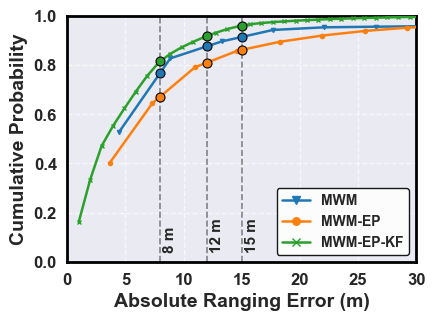

Percentage of ranging estimates within each absolute-error threshold:


,<= 8 m,<= 12 m,<= 15 m
MWM,76.86,87.53,91.34
MWM-EP,67.17,80.91,86.11
MWM-EP-KF,81.42,91.70,95.91



CDF at 8 m:
MWM: 76.86% <= 8 m, 23.14% > 8 m
MWM-EP: 67.17% <= 8 m, 32.83% > 8 m
MWM-EP-KF: 81.42% <= 8 m, 18.58% > 8 m

CDF at 12 m:
MWM: 87.53% <= 12 m, 12.47% > 12 m
MWM-EP: 80.91% <= 12 m, 19.09% > 12 m
MWM-EP-KF: 91.70% <= 12 m, 8.30% > 12 m

CDF at 15 m:
MWM: 91.34% <= 15 m, 8.66% > 15 m
MWM-EP: 86.11% <= 15 m, 13.89% > 15 m
MWM-EP-KF: 95.91% <= 15 m, 4.09% > 15 m


In [80]:
# CDF alone with multiple ranging-error thresholds and percentage table

# Vector-friendly PDF output
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['savefig.dpi']  = 300

thresholds_m = [8, 12, 15]  # metres

sns.set_theme(style="darkgrid")

fig, ax = plt.subplots(figsize=(4.5, 3.2))

cdf_data = {'MWM': (x_A_raw, cdf_A_raw, colors[0], 'v'), 'MWM-EP': (x_B_raw, cdf_B_raw, colors[1], 'o'), 'MWM-EP-KF': (x_B_filt, cdf_B_filt, colors[2], 'x')}

threshold_results = {}

for model, (x, cdf, color, marker) in cdf_data.items():
    x = np.asarray(x)
    cdf = np.asarray(cdf)

    order = np.argsort(x)
    x = x[order]
    cdf = cdf[order]

    ax.plot(x, cdf, label=model, color=color, marker=marker, markersize=3, linewidth=1.8, zorder=3)

    threshold_results[model] = {}

    for th in thresholds_m:
        pct_within = np.interp(th, x, cdf) * 100
        threshold_results[model][f'<= {th} m'] = pct_within
        ax.scatter(th, pct_within / 100, color=color, s=42, edgecolor='black', linewidth=0.8, zorder=5)

# Vertical dashed threshold lines
for th in thresholds_m:
    ax.axvline(th, color='black', linestyle='--', linewidth=1.2, alpha=0.45, zorder=2)
    ax.text(th + 0.25, 0.04, f'{th} m', fontsize=FS_ANN, fontweight='bold', rotation=90, va='bottom', ha='left')

ax.set_xlabel('Absolute Ranging Error (m)', fontsize=FS_LABEL, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=FS_LABEL, fontweight='bold')

ax.set_xlim(0, 30)
ax.set_ylim(0, 1)

ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.2))

ax.tick_params(axis='both', which='major', labelsize=FS_TICK, width=1.0, length=4)
ax.grid(True, linestyle='--', alpha=0.7, zorder=0)

leg = ax.legend(loc='lower right', fontsize=FS_LEGEND, frameon=True, markerscale=1.8, prop={'weight': 'bold', 'size': FS_LEGEND})
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_facecolor('white')
leg.get_frame().set_alpha(0.9)

for s in ax.spines.values():
    s.set_visible(True)
    s.set_linewidth(2.0)
    s.set_color('black')

for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight('bold')

plt.savefig('Figures/cdf_ranging_error_thresholds.png', bbox_inches='tight', facecolor='white')
plt.show()

# Print and display threshold coverage values
threshold_table = pd.DataFrame(threshold_results).T.round(2)

print('Percentage of ranging estimates within each absolute-error threshold:')
display(threshold_table)

for th in thresholds_m:
    print(f'\nCDF at {th} m:')
    for model in threshold_table.index:
        pct = threshold_table.loc[model, f'<= {th} m']
        print(f'{model}: {pct:.2f}% <= {th} m, {100 - pct:.2f}% > {th} m')

In [81]:
# Compute Relative Errors (%) explicitly per device

# Combine necessary data into one DataFrame
error_df = test_df[['device_id', 'distance']].copy()

# Calculate relative errors (%)
error_df['MWM'] = 100 * np.abs(true_distance - d_A_raw) / true_distance
error_df['MWM-KF'] = 100 * np.abs(true_distance - d_A_filt) / true_distance
error_df['MWM-EP'] = 100 * np.abs(true_distance - d_B_raw) / true_distance
error_df['MWM-EP-KF'] = 100 * np.abs(true_distance - d_B_filt) / true_distance

# Define the IQR filtering function
def filter_outliers_iqr(df, cols, multiplier=1.5):
    filtered_df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)]
    return filtered_df

# Using 'error_df' 
cols_to_check = ['MWM', 'MWM-KF', 'MWM-EP', 'MWM-EP-KF']
iqr_filtered_df = filter_outliers_iqr(error_df, cols_to_check)

# Compute mean relative errors per device after robust IQR filtering
mean_errors_per_device = iqr_filtered_df.groupby('device_id')[cols_to_check].mean().round(2)

# Compute overall mean relative errors across all devices
overall_mean_errors = iqr_filtered_df[cols_to_check].mean().round(2)

# Display results 
print("\nMean Relative Errors (%) per Device:\n")
display(mean_errors_per_device)
print("\nOverall Mean Relative Errors (%):\n")
print(overall_mean_errors)


Mean Relative Errors (%) per Device:



,MWM,MWM-KF,MWM-EP,MWM-EP-KF
device_id,,,,
ED0,18.43,18.34,26.13,18.82
ED1,23.74,19.30,27.02,19.70
ED2,16.06,16.43,26.44,17.88
ED3,39.05,30.14,32.45,27.65
ED4,14.63,11.73,26.15,12.99
ED5,20.72,18.69,25.06,16.95



Overall Mean Relative Errors (%):

MWM          22.14
MWM-KF       19.09
MWM-EP       27.17
MWM-EP-KF    18.93
dtype: float64


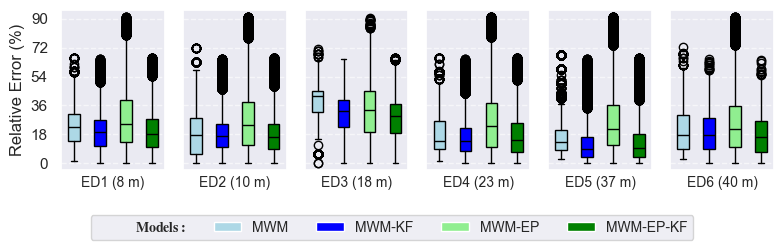

In [82]:
# Box plot visualization for relative errors per device (with IQR filtering)

# Define the IQR filtering function

def filter_outliers_iqr(df, cols, multiplier=1.5):
    """    
    Parameters:
    ------------
    df : pd.DataFrame
        The input DataFrame containing error columns to be filtered.
    cols : list of str
        The column names in `df` on which to apply the IQR filtering.
    multiplier : float, optional (default=1.5)
        The multiplier for the IQR to determine outlier boundaries.
        
    Returns:
    ---------
    filtered_df : pd.DataFrame
        A copy of the input DataFrame with outliers removed based on IQR filtering.
    """
    filtered_df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)]
    return filtered_df

# Apply filtering to error_df
cols_to_check = ['MWM', 'MWM-KF', 'MWM-EP', 'MWM-EP-KF']
robust_relative_error_df = filter_outliers_iqr(error_df, cols_to_check)

# Create one row of 6 subplots
fig, axes = plt.subplots(1, 6, figsize=(8, 2.4), sharey=True)

# Sort devices by mean distance
devices_sorted = robust_relative_error_df.groupby('device_id')['distance'].mean().sort_values().index

# Define box colors (for consistency in plotting and legend)
box_colors = ['lightblue', 'blue', 'lightgreen', 'green']

# Loop through each device and plot 4 boxplots (Raw A, Filtered A, Raw B, Filtered B)
for idx, device in enumerate(devices_sorted):
    device_data = robust_relative_error_df[robust_relative_error_df['device_id'] == device]
    
    data_to_plot = [
        device_data['MWM'],
        device_data['MWM-KF'],
        device_data['MWM-EP'],
        device_data['MWM-EP-KF']
    ]
    
    bp = axes[idx].boxplot(
        data_to_plot,
        patch_artist=True,
        medianprops=dict(color='black')
    )
    
    # Color the boxes using the defined colors
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    
    # Remove numeric x-tick labels so only the device label appears
    axes[idx].set_xticks([])
    axes[idx].set_xticklabels([])

    # Set device label as the x-axis label (e.g., "ED1 (8 m)")
    distance_val = int(device_data["distance"].iloc[0])
    axes[idx].set_xlabel(f'ED{idx+1} ({distance_val} m)', fontsize=10)
    
    # Only the first subplot gets a y-axis label to avoid repetition
    if idx == 0:
        axes[idx].set_ylabel('Relative Error (%)')
    else:
        axes[idx].set_ylabel('')
    
    # Add grid for readability
    axes[idx].grid(True, linestyle='--', alpha=0.6)

#  Create a single inline legend for the entire figure 
# Create a dummy handle for the inline title "Models:" (displayed in bold using mathtext)
dummy_handle = mpatches.Patch(color='none', label=r'$\mathbf{Models:}$')
# Create handles for the four model entries
model_handles = [plt.Rectangle((0, 0), 1, 1, facecolor=color) for color in box_colors]
# Combine the dummy handle with the actual model handles
handles = [dummy_handle] + model_handles
labels = [r'$\mathbf{Models:}$', 'MWM', 'MWM-KF', 'MWM-EP', 'MWM-EP-KF']
# Position the legend in one row at the bottom of the figure
fig.legend(handles, labels, fontsize=10, loc='upper center', 
           bbox_to_anchor=(0.5, 0.1), ncol=5)

# Set y-axis ticks: using MultipleLocator to set the tick spacing to 18 (adjust if needed)
for ax in axes:
    ax.yaxis.set_major_locator(ticker.MultipleLocator(18))

# Adjust layout to make room for the legend and labels
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()

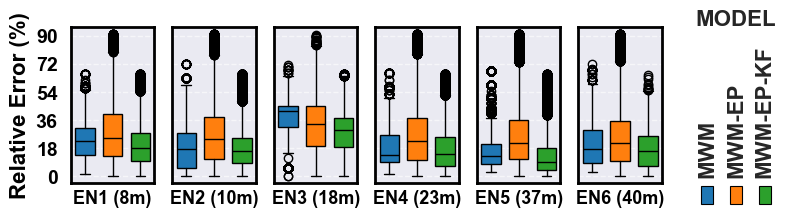

In [83]:
# Font controls
FS_XLABEL       = 13
FS_YLABEL       = 16
FS_TICK         = 14
FS_LEGEND_TITLE = 16
FS_LEGEND_LABEL = 16

# Define the IQR filtering function
def filter_outliers_iqr(df, cols, multiplier=1.5):
    """IQR filter for specified columns."""
    filtered_df = df.copy()
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        filtered_df = filtered_df[(filtered_df[col] >= lower_bound) & (filtered_df[col] <= upper_bound)]
    return filtered_df

# Apply filtering
cols_to_check = ['MWM', 'MWM-KF', 'MWM-EP', 'MWM-EP-KF']
robust_relative_error_df = filter_outliers_iqr(error_df, cols_to_check)

# Figure
fig, axes = plt.subplots(1, 6, figsize=(8, 2.4), sharey=True)

# Colors used for all devices and legend
box_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Devices sorted by mean distance
devices_sorted = robust_relative_error_df.groupby('device_id')['distance'].mean().sort_values().index

# Plot per device
for idx, device in enumerate(devices_sorted[:6]):  # guard in case >6 devices
    ax = axes[idx]
    device_data = robust_relative_error_df[robust_relative_error_df['device_id'] == device]

    data_to_plot = [
        device_data['MWM'],
        device_data['MWM-EP'],
        device_data['MWM-EP-KF']
    ]

    bp = ax.boxplot(data_to_plot, patch_artist=True, medianprops=dict(color='black'), widths=0.7)

    # Fill box faces with your palette
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)

    # Clean x ticks; label with device + distance
    ax.set_xticks([])
    ax.set_xticklabels([])
    distance_val = int(device_data["distance"].iloc[0])
    ax.set_xlabel(f'EN{idx+1} ({distance_val}m)', fontsize=FS_XLABEL, fontweight='bold', color='black')

    # Only left subplot gets y-label
    if idx == 0:
        ax.set_ylabel('Relative Error (%)', fontsize=FS_YLABEL, fontweight='bold', color='black')
    else:
        ax.set_ylabel('')

    # Grid and ticks
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.tick_params(axis='y', labelsize=FS_TICK, labelcolor='black', color='black')
    ax.tick_params(axis='x', labelcolor='black', color='black')
    ax.yaxis.set_major_locator(ticker.MultipleLocator(18))

    # Force black spines for this axis
    for side in ('left', 'right', 'bottom', 'top'):
        sp = ax.spines[side]
        sp.set_visible(True)
        sp.set_linewidth(2)
        sp.set_color('black')
        sp.set_zorder(10)

# Make all tick labels bold
for ax in axes:
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight('bold')

# Tight layout for the 6 subplots only 
plt.tight_layout(rect=[0, 0.1, 0.86, 1])

legend_ax = fig.add_axes([0.87, 0.15, 0.12, 0.75])  # [left, bottom, width, height] in figure coords
legend_ax.axis('off')

# Header "Key" – horizontal, bold
legend_ax.text(0.5, 1.02, 'MODEL', ha='center', va='bottom',
               fontsize=16, fontweight='bold', transform=legend_ax.transAxes)

labels = ['MWM', 'MWM-EP', 'MWM-EP-KF']
xs = [0.2, 0.5, 0.8]  # x positions for the three entries in legend_ax coordinates

for x, label, color in zip(xs, labels, box_colors):
    # Colored box
    rect = Rectangle((x - 0.06, 0.05), 0.12, 0.10,
                     facecolor=color, edgecolor='black', linewidth=0.8,
                     transform=legend_ax.transAxes, clip_on=False)
    legend_ax.add_patch(rect)

    # Rotated label above the box
    legend_ax.text(x, 0.2, label,
                   ha='center', va='bottom',
                   rotation=90,
                   fontsize=FS_LEGEND_LABEL,
                   fontweight='bold',
                   transform=legend_ax.transAxes)

fig.patch.set_facecolor('white')
plt.savefig('Figures/relative_errors_boxplots_per_device.pdf', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.savefig('Figures/relative_errors_boxplots_per_device.png', dpi=1000, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

In [84]:
# Device-level paired summaries + safe Wilcoxon tests

models = ['MWM', 'MWM-EP', 'MWM-EP-KF']

# 1) Device-level summaries aligned with the boxplot figure
#    (uses the same IQR-filtered relative-error frame)

device_rel_mean = (
    robust_relative_error_df
    .groupby('device_id')[models]
    .mean()
    .sort_index()
)

device_rel_median = (
    robust_relative_error_df
    .groupby('device_id')[models]
    .median()
    .sort_index()
)

print("\nDevice-level mean relative error (%)")
print(device_rel_mean.round(3))

print("\nDevice-level median relative error (%)")
print(device_rel_median.round(3))


# 2) Device-level absolute distance-error summaries
#    (full held-out test set, no IQR filtering)

device_abs_df = test_df[['device_id', 'distance']].copy()
device_abs_df['MWM'] = np.abs(true_distance - d_A_raw)
device_abs_df['MWM-EP'] = np.abs(true_distance - d_B_raw)
device_abs_df['MWM-EP-KF'] = np.abs(true_distance - d_B_filt)

device_abs_mae = (
    device_abs_df
    .groupby('device_id')[models]
    .mean()
    .sort_index()
)

device_abs_median = (
    device_abs_df
    .groupby('device_id')[models]
    .median()
    .sort_index()
)

print("\nDevice-level mean absolute distance error (m)")
print(device_abs_mae.round(3))

print("\nDevice-level median absolute distance error (m)")
print(device_abs_median.round(3))


# 3) Safe paired Wilcoxon tests on the SIX device summaries
#    Use two-sided tests; lower is better

def paired_wilcoxon(summary_df, better='MWM-EP-KF', worse='MWM-EP', label=''):
    x = summary_df[better].to_numpy()
    y = summary_df[worse].to_numpy()
    diffs = x - y  # negative means better model has lower error

    # exact counts for directionality
    n_better = int(np.sum(diffs < 0))
    n_worse  = int(np.sum(diffs > 0))
    n_equal  = int(np.sum(diffs == 0))

    # Wilcoxon on paired device summaries
    stat, p = wilcoxon(x, y, alternative='two-sided', zero_method='wilcox', method='exact')

    out = {
        'comparison': f'{better} vs {worse}',
        'summary': label,
        'n_devices': len(diffs),
        'n_better': n_better,
        'n_worse': n_worse,
        'n_equal': n_equal,
        'wilcoxon_stat': float(stat),
        'p_value': float(p),
        'mean_delta': float(np.mean(diffs)),    # negative is good for better model
        'median_delta': float(np.median(diffs))
    }
    return out

results = []
results.append(paired_wilcoxon(device_rel_mean,   better='MWM-EP-KF', worse='MWM-EP', label='mean relative error (%)'))
results.append(paired_wilcoxon(device_rel_mean,   better='MWM-EP-KF', worse='MWM',    label='mean relative error (%)'))
results.append(paired_wilcoxon(device_rel_median, better='MWM-EP-KF', worse='MWM-EP', label='median relative error (%)'))
results.append(paired_wilcoxon(device_rel_median, better='MWM-EP-KF', worse='MWM',    label='median relative error (%)'))
results.append(paired_wilcoxon(device_abs_mae,    better='MWM-EP-KF', worse='MWM-EP', label='mean absolute distance error (m)'))
results.append(paired_wilcoxon(device_abs_mae,    better='MWM-EP-KF', worse='MWM',    label='mean absolute distance error (m)'))
results.append(paired_wilcoxon(device_abs_median, better='MWM-EP-KF', worse='MWM-EP', label='median absolute distance error (m)'))
results.append(paired_wilcoxon(device_abs_median, better='MWM-EP-KF', worse='MWM',    label='median absolute distance error (m)'))

results_df = pd.DataFrame(results)
print("\nPaired Wilcoxon results on device-level summaries")
print(results_df.round(6).to_string(index=False))


Device-level mean relative error (%)
              MWM  MWM-EP  MWM-EP-KF
device_id                           
ED0        18.432  26.129     18.823
ED1        23.745  27.017     19.702
ED2        16.064  26.441     17.879
ED3        39.046  32.452     27.650
ED4        14.627  26.150     12.987
ED5        20.718  25.060     16.954

Device-level median relative error (%)
              MWM  MWM-EP  MWM-EP-KF
device_id                           
ED0        17.540  23.947     16.078
ED1        22.744  24.352     18.363
ED2        13.741  22.863     14.183
ED3        42.044  33.367     29.467
ED4        12.855  21.404      9.256
ED5        17.243  21.219     16.243

Device-level mean absolute distance error (m)
              MWM  MWM-EP  MWM-EP-KF
device_id                           
ED0        18.546   6.931      3.207
ED1        12.482   6.273      2.105
ED2        17.714   9.031      6.030
ED3        21.086   8.036      5.376
ED4        10.893  11.887      6.096
ED5         8.397  10.45